In [34]:
# ==================================================
# Task 1.1 - Load and Inspect Data
# ==================================================

# Import pandas library
import pandas as pd

# Load the railway dataset
df = pd.read_csv("Railway_info.csv")

# Display first 10 rows of the dataset
df.head(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
5,421,LKO-SVDK FTR,LUCKNOW JN.,SHRI MATA VAISHNO DEVI KATRA,Tuesday
6,422,SVDK-LKO FTR,SHRI MATA VAISHNO DEVI KATRA,LUCKNOW JN.,Monday
7,477,FTR TRAIN NO,SIRSA,SIRSA,Sunday
8,502,RJPB-UMB FTR,RAJENDRANAGAR TERMINAL,AMBALA CANTT JN,Monday
9,504,PNBE-BTI FTR,PATNA JN.,BATHINDA JN,Wednesday


In [35]:
# ==================================================
# Check dataset structure
# ==================================================

# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Train_No                  11113 non-null  int64 
 1   Train_Name                11113 non-null  object
 2   Source_Station_Name       11113 non-null  object
 3   Destination_Station_Name  11113 non-null  object
 4   days                      11113 non-null  object
dtypes: int64(1), object(4)
memory usage: 434.2+ KB


In [36]:
# ==================================================
# Check missing values
# ==================================================

# Count missing values in each column
df.isnull().sum()

Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64

In [37]:
# ==================================================
# Display all column names
# ==================================================

# Show all columns in the dataset
print(df.columns)

Index(['Train_No', 'Train_Name', 'Source_Station_Name',
       'Destination_Station_Name', 'days'],
      dtype='object')


In [38]:
# ==================================================
# Task 1.2 - Basic Statistics
# Total Number of Trains
# ==================================================

print("Total Number of Trains:", len(df))

Total Number of Trains: 11113


In [39]:
# Count unique source stations

print("Unique Source Stations:",
      df["Source_Station_Name"].nunique())


Unique Source Stations: 921


In [40]:
# Count unique destination stations

print("Unique Destination Stations:",
      df["Destination_Station_Name"].nunique())

Unique Destination Stations: 924


In [41]:
# Top 10 most common source stations

df["Source_Station_Name"].value_counts().head(10)

Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
THANE            186
PANVEL           141
TAMBARAM         140
MOOR MARKET      135
VELACHEERY       115
Name: count, dtype: int64

In [42]:
# Top 10 most common destination stations

df["Destination_Station_Name"].value_counts().head(10)

Destination_Station_Name
CST-MUMBAI       514
SEALDAH          373
CHENNAI BEACH    342
HOWRAH JN.       337
KALYAN JN        284
THANE            194
PANVEL           144
TAMBARAM         140
MOOR MARKET      132
VELACHEERY       118
Name: count, dtype: int64

In [43]:
# ==================================================
# Task 1.3 - Data Cleaning
# Verify Missing Values
# ==================================================

print(df.isnull().sum())

Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64


In [44]:
# Standardize source station names

df["Source_Station_Name"] = (
    df["Source_Station_Name"].str.upper()
)

# Standardize destination station names

df["Destination_Station_Name"] = (
    df["Destination_Station_Name"].str.upper()
)

In [45]:
# Display sample records after cleaning

df[["Source_Station_Name",
    "Destination_Station_Name"]].head()

,Source_Station_Name,Destination_Station_Name
0,SAWANTWADI ROAD,MADGOAN JN.
1,MADGOAN JN.,SAWANTWADI ROAD
2,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS
3,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG
4,AURANGABAD,VARANASI JN.


In [46]:
# Check how operating days are stored

df["days"].head(20)

0      Saturday
1        Friday
2        Friday
3     Wednesday
4      Saturday
5       Tuesday
6        Monday
7        Sunday
8        Monday
9     Wednesday
10       Friday
11    Wednesday
12       Friday
13     Thursday
14     Thursday
15      Tuesday
16      Tuesday
17     Thursday
18       Monday
19       Sunday
Name: days, dtype: object

In [47]:
# ==================================================
# Task 2.1 - Filter trains operating on Saturday
# ==================================================

saturday_trains = df[df["days"] == "Saturday"]

saturday_trains.head(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
21,1196,NGP-KRMI SPL,NAGPUR JN.(CR),KARMALI,Saturday
28,1706,JBP-BDTS SF,JABALPUR,BANDRA TERMINUS,Saturday
45,2834,SRC-RJT SF A,SANTRAGACHI JN.,RAJKOT,Saturday
54,3305,DHN-KUSUNDA,DHANBAD JN.,KUSUNDA,Saturday
59,3502,ANVT-JSME BI,ANAND VIHAR TERMINAL,JASIDIH JN.,Saturday
77,4802,MKN PBC PASS,MAKRANA JN.,PARVATSAR CITY,Saturday
91,5066,LJN-CPR-EXP,LUCKNOW JN.,CHHAPRA JN.,Saturday
95,5306,FBD- CPA EXP,FARRUKHABAD JN,KANPUR ANWARGANJ,Saturday


In [48]:
# Count trains operating on Saturday

print("Number of Saturday Trains:",
      len(saturday_trains))

Number of Saturday Trains: 1441


In [49]:
# Create dataframe for trains starting from CST-MUMBAI

cst_trains = df[
    df["Source_Station_Name"] == "CST-MUMBAI"
]

cst_trains.head(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
14,1011,CSMT-NGP SF,CST-MUMBAI,NAGPUR JN.(CR),Thursday
31,2025,CSMT-KRMI SF,CST-MUMBAI,KARMALI,Tuesday
273,10103,MANDOVI EXPR,CST-MUMBAI,MADGOAN JN.,Thursday
275,10111,KONKAN KANYA,CST-MUMBAI,MADGOAN JN.,Friday
285,11007,DECCAN EXPRE,CST-MUMBAI,PUNE JN.,Wednesday
287,11009,SINHAGAD EXP,CST-MUMBAI,PUNE JN.,Thursday
297,11019,KONARK EXPRE,CST-MUMBAI,BHUBANESWAR,Friday
301,11023,SAHYADRI EXP,CST-MUMBAI,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Wednesday
305,11027,CSMT-MAS MAI,CST-MUMBAI,CHENNAI CENTRAL,Sunday
307,11029,KOYNA EXPRES,CST-MUMBAI,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Tuesday


In [50]:
# Count trains starting from CST-MUMBAI

print("Number of Trains Starting from CST-MUMBAI:",
      len(cst_trains))

Number of Trains Starting from CST-MUMBAI: 513


In [51]:
# ==================================================
# Task 2.2 - Grouping and Aggregation
# Count trains from each source station
# ==================================================

source_station_count = (
    df.groupby("Source_Station_Name")
      .size()
      .reset_index(name="Train_Count")
)

source_station_count.head(10)

,Source_Station_Name,Train_Count
0,ABHANPUR JN.,2
1,ABOHAR,1
2,ABU ROAD,1
3,ACHHNERA JN.,1
4,ADILABAD,5
5,ADRA,16
6,ADRAJ MOTI,2
7,AGARTALA,8
8,AGRA FORT,6
9,AGRA CANTT,16


In [52]:
# Display top 10 stations by train count

source_station_count.sort_values(
    by="Train_Count",
    ascending=False
).head(10)

,Source_Station_Name,Train_Count
224,CST-MUMBAI,513
773,SEALDAH,372
201,CHENNAI BEACH,339
373,HOWRAH JN.,338
426,KALYAN JN,285
843,THANE,186
660,PANVEL,141
832,TAMBARAM,140
585,MOOR MARKET,135
894,VELACHEERY,115


In [53]:
# Count trains for each day

day_wise_count = (
    df.groupby("days")
      .size()
      .reset_index(name="Train_Count")
)

day_wise_count

,days,Train_Count
0,Friday,1471
1,Fridayd,178
2,Monday,1342
3,Mondayd,161
4,Saturday,1441
5,Saturdayd,152
6,Sunday,1432
7,Sundayd,170
8,Thursday,1372
9,Thursdayd,154


In [54]:
# Average trains per day

print(
    "Average Trains Per Day:",
    round(day_wise_count["Train_Count"].mean(), 2)
)

Average Trains Per Day: 793.79


In [55]:
# ==================================================
# Task 2.3 - Data Enrichment
# Categorize trains as Weekday or Weekend
# ==================================================

def categorize_day(day):

    if "Saturday" in day or "Sunday" in day:
        return "Weekend"

    else:
        return "Weekday"


df["Day_Category"] = df["days"].apply(categorize_day)

df[["days", "Day_Category"]].head(20)

,days,Day_Category
0,Saturday,Weekend
1,Friday,Weekday
2,Friday,Weekday
3,Wednesday,Weekday
4,Saturday,Weekend
5,Tuesday,Weekday
6,Monday,Weekday
7,Sunday,Weekend
8,Monday,Weekday
9,Wednesday,Weekday


In [56]:
# Count Weekday and Weekend trains

df["Day_Category"].value_counts()

Day_Category
Weekday    7918
Weekend    3195
Name: count, dtype: int64

In [57]:
# ==================================================
# Task 3.1 - Pattern Analysis
# Distribution of train operations by day
# ==================================================

day_distribution = df["days"].value_counts()

print(day_distribution)

days
Friday        1471
Tuesday       1454
Wednesday     1448
Saturday      1441
Sunday        1432
Thursday      1372
Monday        1342
Fridayd        178
Tuesdayd       174
Sundayd        170
Wednesdayd     164
Mondayd        161
Thursdayd      154
Saturdayd      152
Name: count, dtype: int64


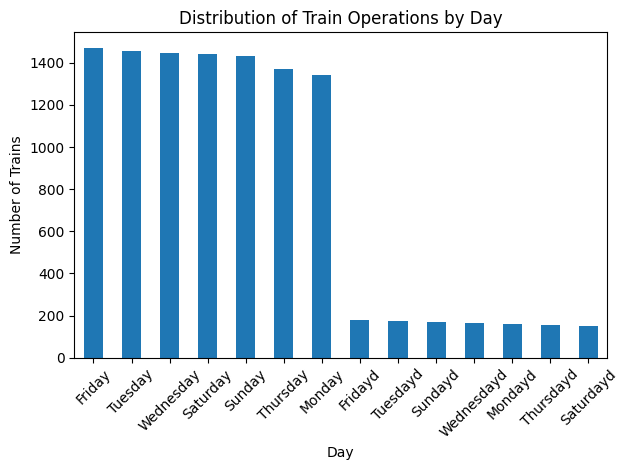

In [58]:
# Import matplotlib

import matplotlib.pyplot as plt

# Create bar chart

day_distribution.plot(kind="bar")

plt.title("Distribution of Train Operations by Day")
plt.xlabel("Day")
plt.ylabel("Number of Trains")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [59]:
# ==================================================
# Task 3.2 - Correlation and Insights
# ==================================================

# Analyze the distribution of weekday and weekend trains

df["Day_Category"].value_counts()

Day_Category
Weekday    7918
Weekend    3195
Name: count, dtype: int64

In [60]:
# ==================================================
# Task 3.2 - Percentage Distribution Analysis
# ==================================================

# Calculate percentage of weekday and weekend trains

category_percent = (
    df["Day_Category"]
    .value_counts(normalize=True) * 100
)

print(category_percent)

Day_Category
Weekday    71.249888
Weekend    28.750112
Name: proportion, dtype: float64


In [61]:
# ==================================================
# Task 3.2 - Key Insights from the Dataset
# ==================================================

# Insights:
#
# 1. The dataset contains 11,113 train records.
#
# 2. CST-MUMBAI is the busiest source station
#    with 513 originating trains.
#
# 3. CST-MUMBAI is the busiest destination station
#    with 514 terminating trains.
#
# 4. Weekday operations are significantly higher
#    than weekend operations.
#
# 5. Friday has the highest train count among
#    the standard weekdays.
#
# 6. The railway network covers more than
#    900 unique source and destination stations.

print("Task 3.2 Analysis Completed")

Task 3.2 Analysis Completed


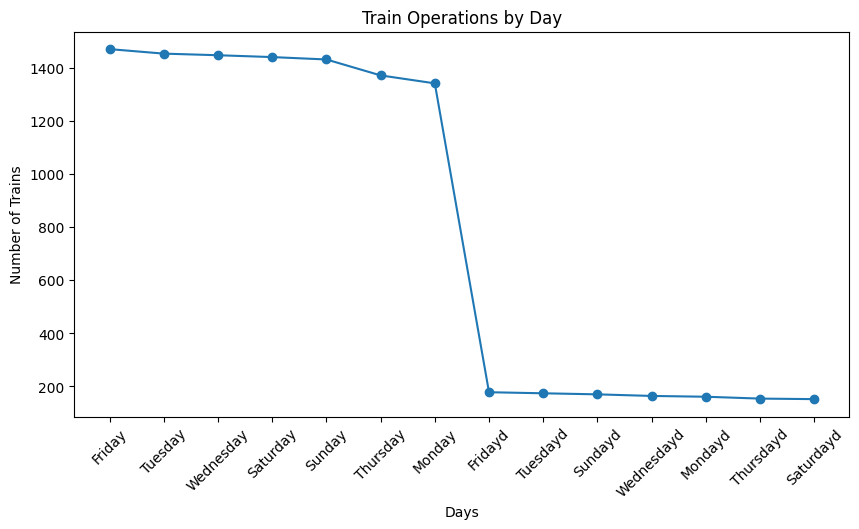

In [62]:
# ==================================================
# Task 4.1 - Data Visualization
# Visualization 2: Line Chart
# ==================================================

import matplotlib.pyplot as plt

# Count trains operating on each day

day_counts = df["days"].value_counts()

# Create line chart

plt.figure(figsize=(10,5))

plt.plot(
    day_counts.index,
    day_counts.values,
    marker="o"
)

# Add chart title and labels

plt.title("Train Operations by Day")
plt.xlabel("Days")
plt.ylabel("Number of Trains")

# Rotate labels for readability

plt.xticks(rotation=45)

plt.show()

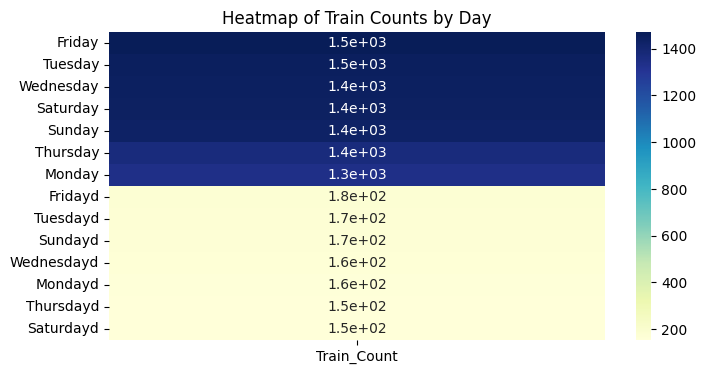

In [63]:
# ==================================================
# Task 4.2 - Data Visualization
# Visualization 3: Heatmap
# ==================================================

import seaborn as sns
import matplotlib.pyplot as plt

day_counts = df["days"].value_counts().reset_index()
day_counts.columns = ["Day", "Train_Count"]

plt.figure(figsize=(8,4))

sns.heatmap(
    day_counts[["Train_Count"]],
    annot=True,
    cmap="YlGnBu",
    yticklabels=day_counts["Day"]
)

plt.title("Heatmap of Train Counts by Day")

plt.show()

In [64]:
# ==================================================
# Internship Task Completion Summary
# ==================================================

print("Task 1.1 - Completed")
print("Task 1.2 - Completed")
print("Task 1.3 - Completed")
print("Task 2.1 - Completed")
print("Task 2.2 - Completed")
print("Task 2.3 - Completed")
print("Task 3.1 - Completed")
print("Task 3.2 - Completed")
print("Task 4.1 - Completed")
print("Task 4.2 - Completed")

print("\nRailway Data Analysis Project Completed Successfully")

Task 1.1 - Completed
Task 1.2 - Completed
Task 1.3 - Completed
Task 2.1 - Completed
Task 2.2 - Completed
Task 2.3 - Completed
Task 3.1 - Completed
Task 3.2 - Completed
Task 4.1 - Completed
Task 4.2 - Completed

Railway Data Analysis Project Completed Successfully
